# EDA

In [1]:
%load_ext autoreload
%autoreload 2
import medmnist
import torch 
import random 
import numpy as np
import torch.nn as nn 
import torch.nn.functional as F 
import torch.optim as optim
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from utils import *
from medmnist import PathMNIST,INFO
from pathlib import Path
from tqdm import tqdm
from torchinfo import summary

In [2]:
ROOT_DIR = "./data"
# Create the directory if it doesn't exist
Path(ROOT_DIR).mkdir(parents=True, exist_ok=True)
SEED = 42
IMG_SIZE = (28, 28)
HIDDEN_SIZE = 256
CHANNELS = 3
NUM_CLASSES = 9
BATCH_SIZE = 64
EPOCHS_MLP = 10
EPOCHS_CNN = 40
EPOCHS_VIT = 10
LEARNING_RATE = 1e-3
LEARNING_RATE_VIT = 1e-3

In [3]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
dataset = PathMNIST(root=ROOT_DIR, split="train", download=True)

In [5]:
# Load PathMNIST info
data_flag = 'pathmnist'
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

In [6]:
info

{'python_class': 'PathMNIST',
 'description': 'The PathMNIST is based on a prior study for predicting survival from colorectal cancer histology slides, providing a dataset (NCT-CRC-HE-100K) of 100,000 non-overlapping image patches from hematoxylin & eosin stained histological images, and a test dataset (CRC-VAL-HE-7K) of 7,180 image patches from a different clinical center. The dataset is comprised of 9 types of tissues, resulting in a multi-class classification task. We resize the source images of 3×224×224 into 3×28×28, and split NCT-CRC-HE-100K into training and validation set with a ratio of 9:1. The CRC-VAL-HE-7K is treated as the test set.',
 'url': 'https://zenodo.org/records/10519652/files/pathmnist.npz?download=1',
 'MD5': 'a8b06965200029087d5bd730944a56c1',
 'url_64': 'https://zenodo.org/records/10519652/files/pathmnist_64.npz?download=1',
 'MD5_64': '55aa9c1e0525abe5a6b9d8343a507616',
 'url_128': 'https://zenodo.org/records/10519652/files/pathmnist_128.npz?download=1',
 'MD5

In [7]:
print(f"Number of samples: {len(dataset)}")

Number of samples: 89996


In [8]:
for key, value in dataset.info['label'].items():
    print(f"Class {key} : {value}")

Class 0 : adipose
Class 1 : background
Class 2 : debris
Class 3 : lymphocytes
Class 4 : mucus
Class 5 : smooth muscle
Class 6 : normal colon mucosa
Class 7 : cancer-associated stroma
Class 8 : colorectal adenocarcinoma epithelium


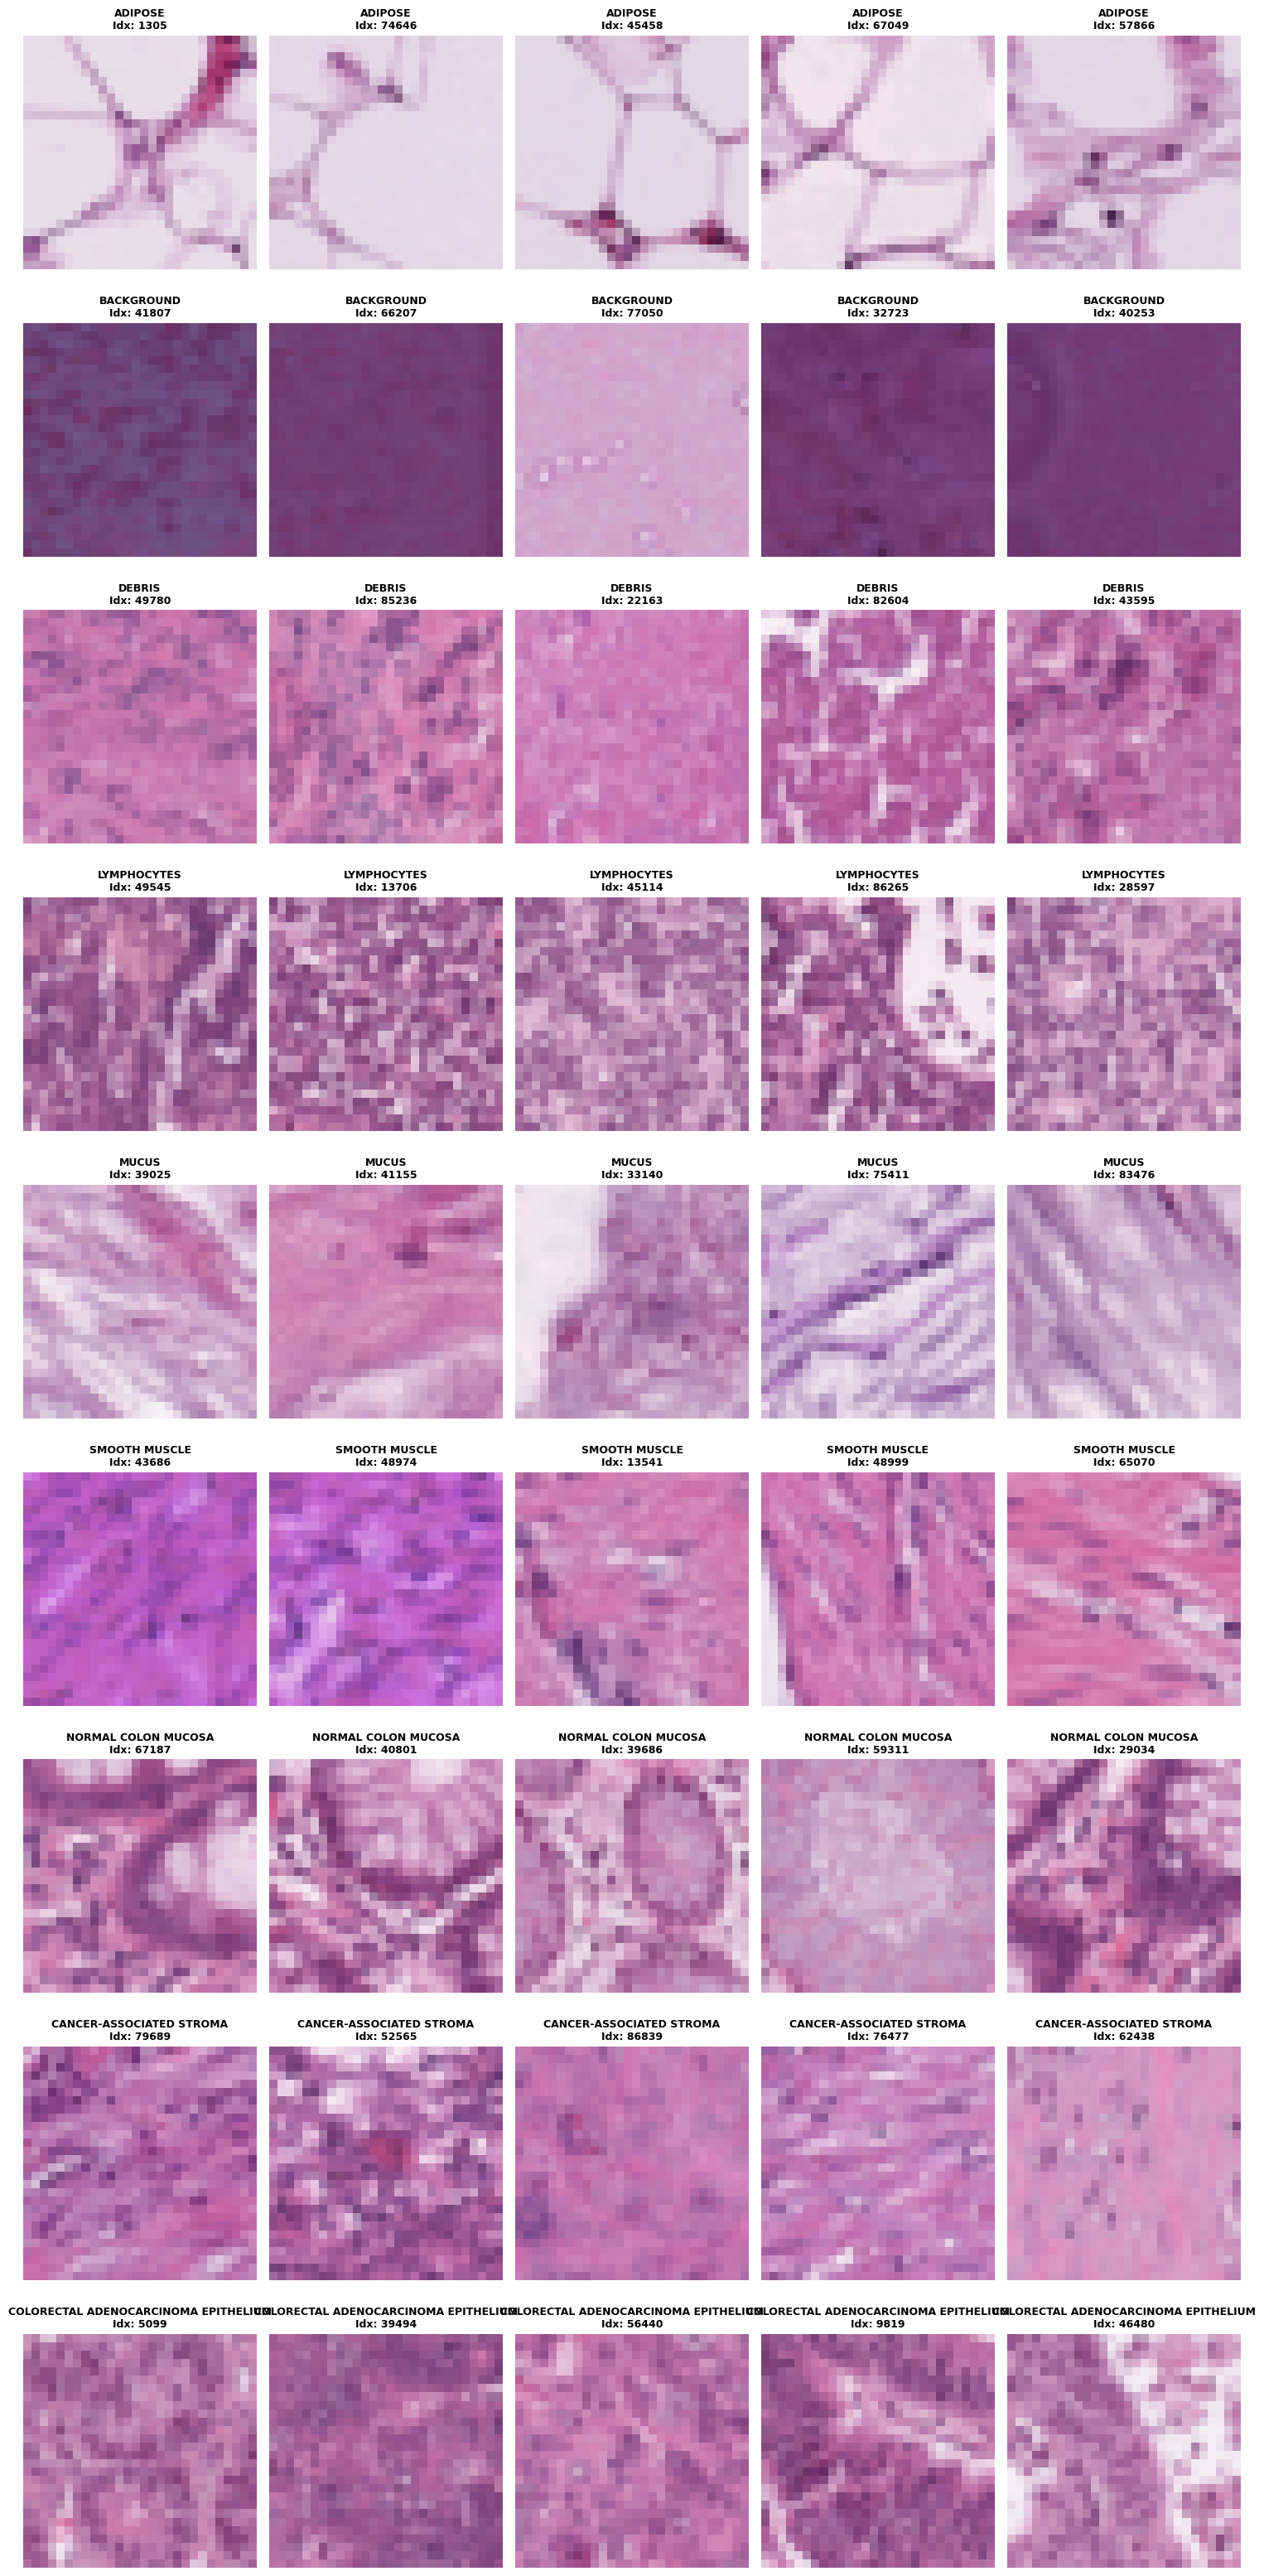

In [9]:
display_medmnist_samples(dataset,"*",5)

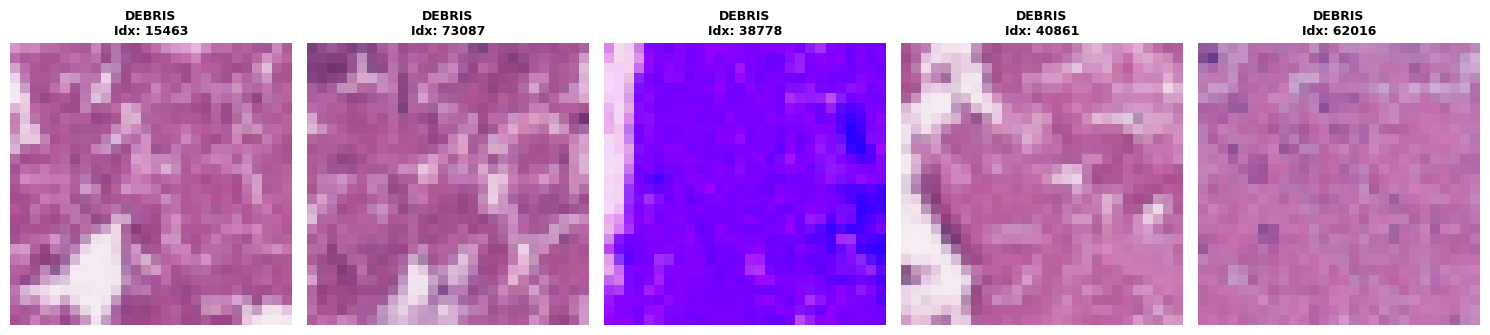

In [10]:
display_medmnist_samples(dataset,"debris",5)

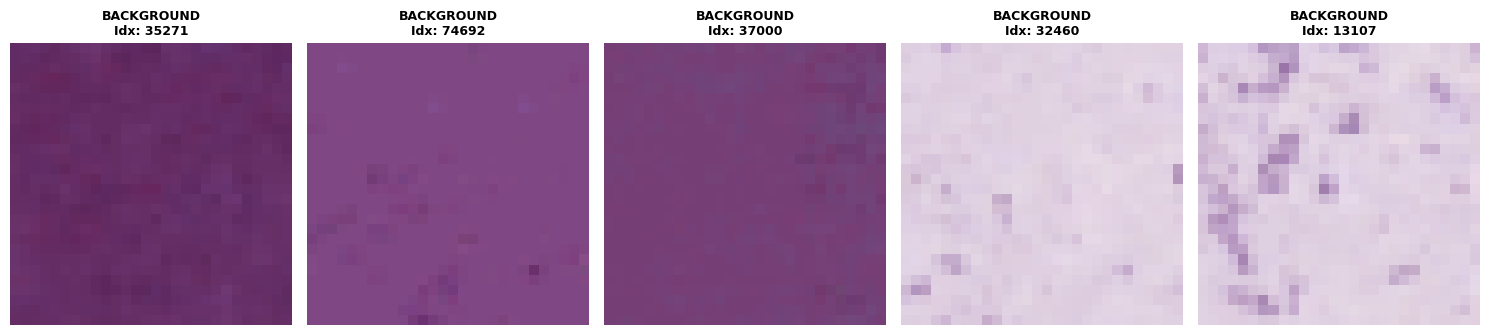

In [11]:
display_medmnist_samples(dataset,"background",5)

In [12]:
print_dataset_structure(dataset)

--- Dataset Structure: PATHMNIST ---
Total samples: 89996
Image shape: (89996, 28, 28, 3)
Labels shape: (89996, 1)
Mode: RGB


In [13]:
plot_class_distribution(dataset)

--- Pixel Stats: Mean=168.25, Std=43.36, Min=0, Max=255 ---


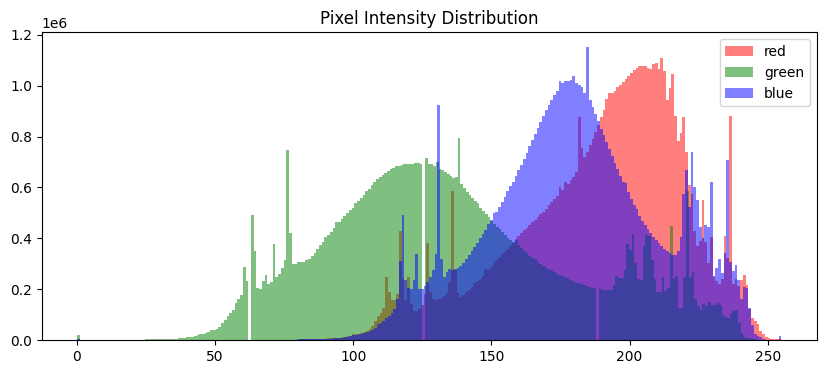

In [14]:
show_pixel_stats(dataset)

--- Stats for Image Index: 15795 (Seed: 42) ---
Mean: 108.66 | Std: 27.71 | Min: 11 | Max: 139
Shape: (28, 28, 3)


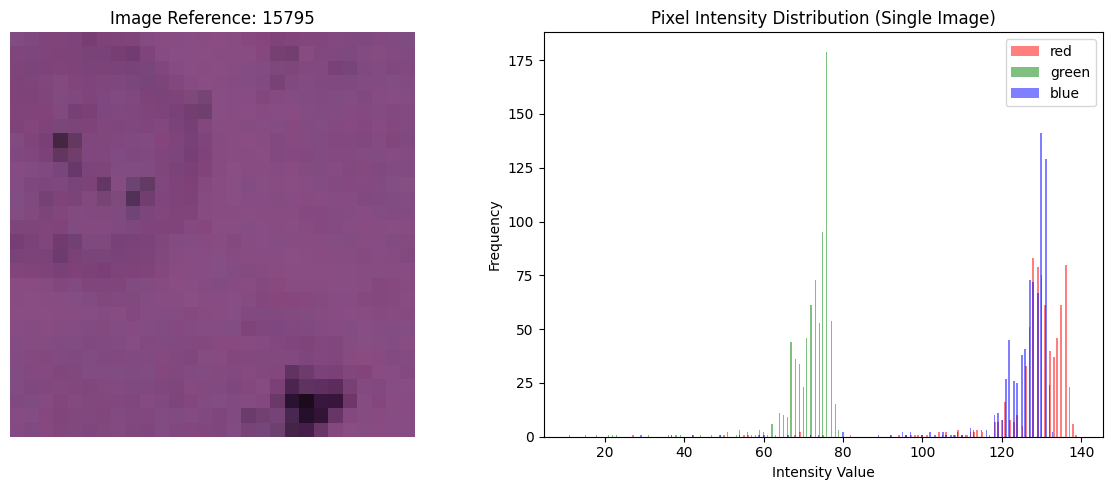

In [15]:
show_random_pixel_stats(dataset)

Nous avons calculé la moyenne et l’écart-type des intensités de pixels pour chaque canal RGB sur une image du jeu d’entraînement. Les valeurs obtenues sont différentes des statistiques d’ImageNet. Cela est attendu car les images du dataset PathMNIST sont des images histopathologiques avec des distributions de couleurs spécifiques (principalement des teintes roses et violettes dues à la coloration H&E), tandis qu’ImageNet contient des images naturelles avec une distribution de couleurs plus variée. Les statistiques de pixels ne sont donc pas proches de celles d’ImageNet.

# Preparing the data

In [16]:
transform_train = transforms.Compose([
    # 1. Random data augmentation
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    
    # 2. Tensor conversion
    transforms.ToTensor(),
    
    # 3. ImageNet normalization
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [17]:
# 2. Load the 3 splits (it only downloads once!)
train_dataset = PathMNIST(root=ROOT_DIR, split="train", transform=transform_train, download=False)
val_dataset   = PathMNIST(root=ROOT_DIR, split="val",   transform=transform_test, download=False)
test_dataset  = PathMNIST(root=ROOT_DIR, split="test",  transform=transform_test, download=False)

# 3. Create your loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# MLP

In [18]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, dropout_prob=0.2): # Dropout réduit
        super(MLP, self).__init__()
        
        # Layer 1
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.bn1 = nn.BatchNorm1d(hidden_size) # BatchNorm
        
        # Layer 2 (Option: hidden_size // 2 for funnel effect)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.bn2 = nn.BatchNorm1d(hidden_size)
        
        # Output layer
        self.fc3 = nn.Linear(hidden_size, num_classes)
        
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        
        # Bloc 1
        x = self.fc1(x)
        x = self.bn1(x) # Normalise avant l'activation
        x = F.relu(x)
        x = self.dropout(x)
        
        # Bloc 2
        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)
        
        # Sortie (Pas de ReLU ni de Dropout ici !)
        return self.fc3(x)

In [19]:
baseline = MLP(input_size=IMG_SIZE[0] * IMG_SIZE[1] * CHANNELS, hidden_size=HIDDEN_SIZE, num_classes=NUM_CLASSES)

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
baseline = baseline.to(device)
print(baseline)

MLP(
  (fc1): Linear(in_features=2352, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=256, out_features=9, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)


In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=LEARNING_RATE)

Training loop

In [22]:
def train_and_evaluate(model, train_loader, val_loader, criterion, optimizer, epochs, device):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device).squeeze().long()
            
            # Forward + Backward
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            # Stats
            train_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            train_correct += predicted.eq(labels).sum().item()
            train_total += labels.size(0)
            loop.set_postfix(loss=loss.item())

        # --- VALIDATION PHASE ---
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device).squeeze().long()
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total += labels.size(0)

        # Store metrics
        history['train_loss'].append(train_loss / train_total)
        history['train_acc'].append(100. * train_correct / train_total)
        history['val_loss'].append(val_loss / val_total)
        history['val_acc'].append(100. * val_correct / val_total)
        
        print(f"Summary Epoch {epoch+1}: Val Loss: {history['val_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]:.2f}%")
        
    return history

In [23]:
history = train_and_evaluate(baseline, train_loader, val_loader, criterion, optimizer, EPOCHS_MLP, device)

Epoch 1/10: 100%|██████████| 1407/1407 [00:10<00:00, 129.80it/s, loss=0.586]


Summary Epoch 1: Val Loss: 0.9263 | Val Acc: 65.47%


Epoch 2/10: 100%|██████████| 1407/1407 [00:10<00:00, 133.56it/s, loss=1.05] 


Summary Epoch 2: Val Loss: 0.8597 | Val Acc: 67.90%


Epoch 3/10: 100%|██████████| 1407/1407 [00:10<00:00, 133.94it/s, loss=0.726]


...

Summary Epoch 8: Val Loss: 0.7843 | Val Acc: 70.11%


Epoch 9/10: 100%|██████████| 1407/1407 [00:10<00:00, 129.99it/s, loss=0.758]


Summary Epoch 9: Val Loss: 0.7753 | Val Acc: 70.06%


Epoch 10/10: 100%|██████████| 1407/1407 [00:10<00:00, 130.27it/s, loss=0.714]


Summary Epoch 10: Val Loss: 0.7600 | Val Acc: 71.39%


Test accuracy:
0.647075208913649
Confusion matrix:
[[1293   11    4    0    2   24    0    0    4]
 [   0  847    0    0    0    0    0    0    0]
 [   0    9  128    0    0  176    0   26    0]
 [  82    4   19  336    1    0   27    0  165]
 [ 154  342    1   20  475    2   30    2    9]
 [   0   62  255    0    1  262    0   11    1]
 [  30    1   18   12   30   12  276    0  362]
 [   1    6  160    0    8   61    7  133   45]
 [   8   11  178    8   16    7  106    3  896]]


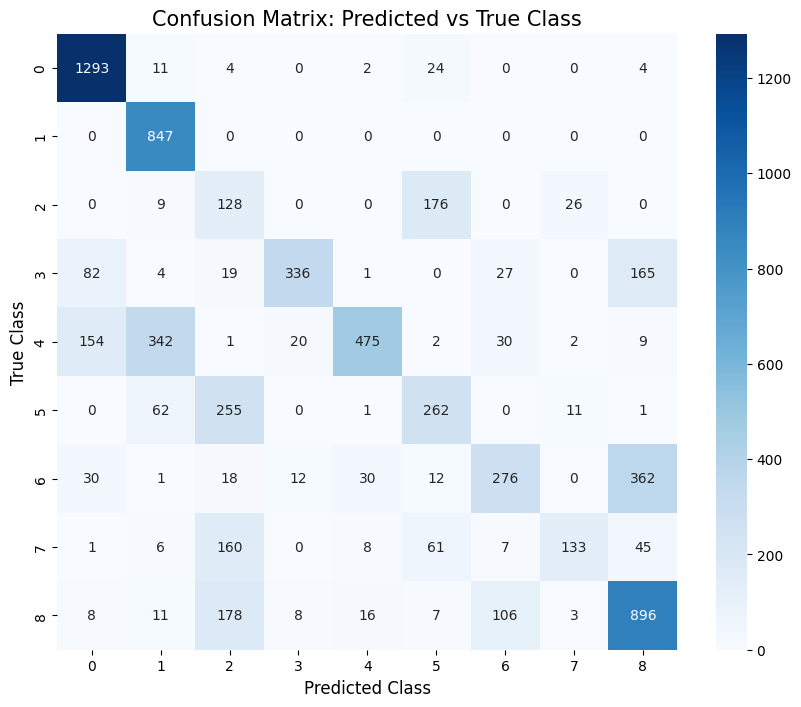

In [ ]:
test_acc = eval_test(baseline, test_loader, device)

print("Test accuracy:")
print("="*20)
print(test_acc[0])
print("Confusion matrix:")
print("="*20)
print(test_acc[1])
# noms des classes PathMNIST
class_names = INFO["pathmnist"]["label"]

# matrice de confusion
plot_confusion_matrix(baseline, test_loader, device, class_names);

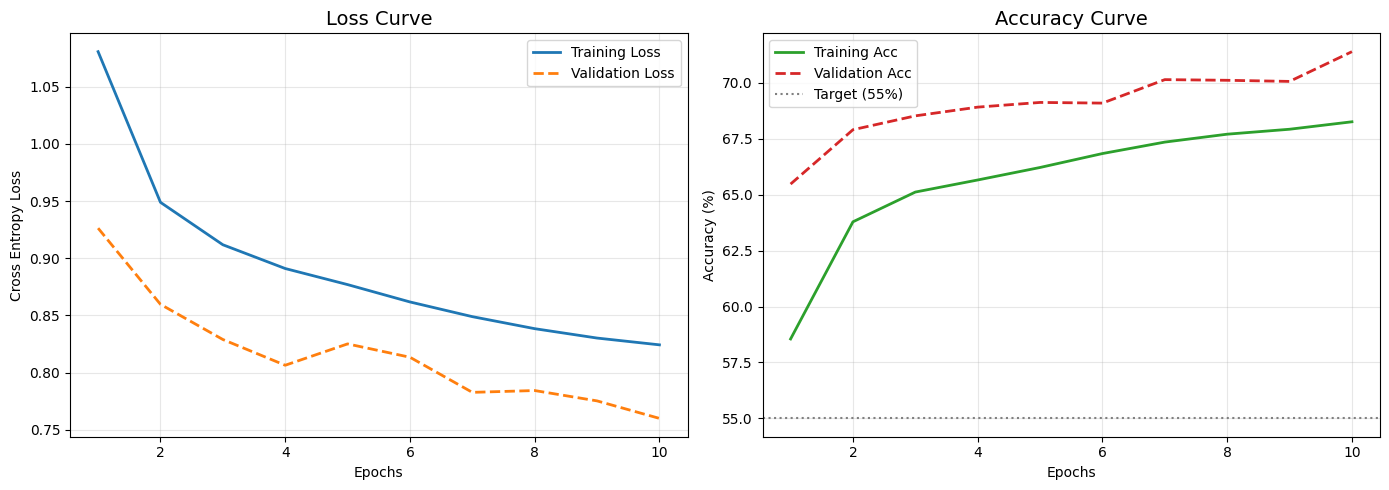

In [25]:
plot_training_history(history)

In [26]:
evaluate_test_accuracy(baseline, test_loader, device)

64.70752089136491

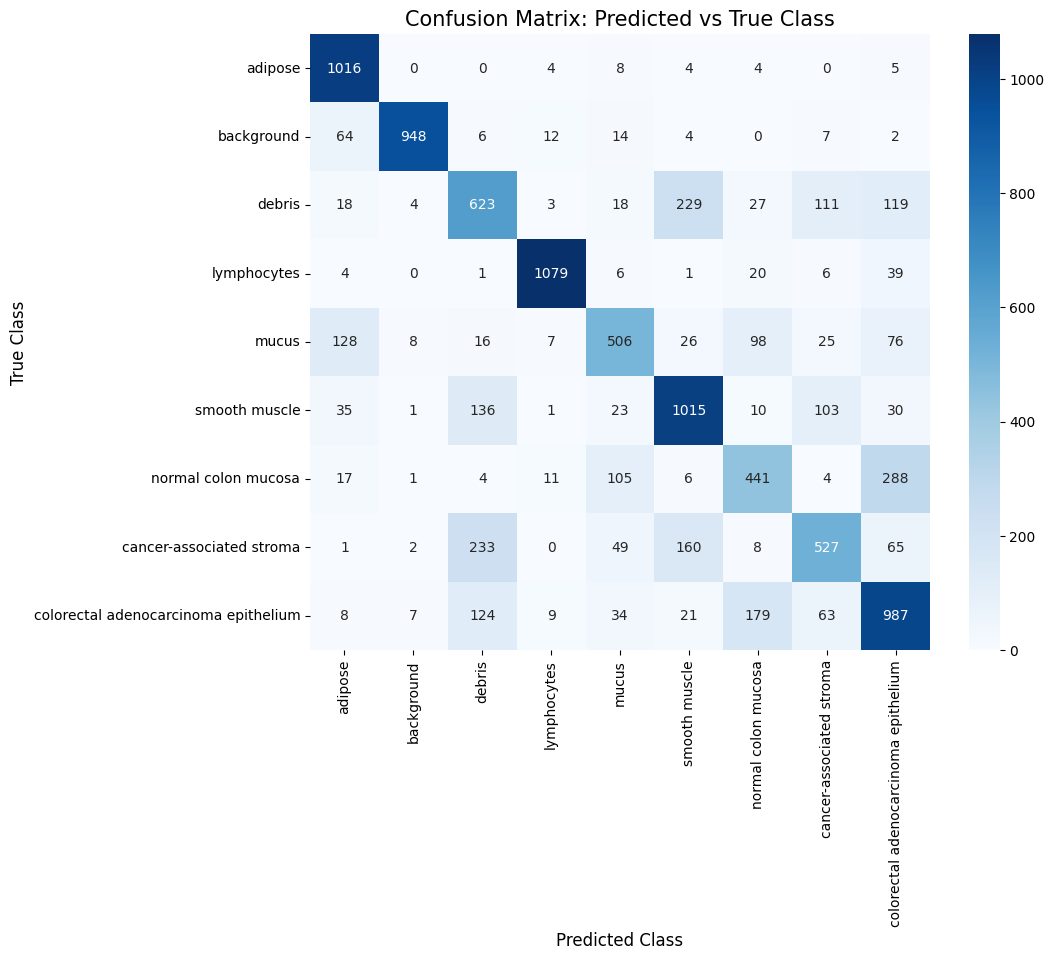

In [27]:
class_names = [train_dataset.info['label'][str(i)] for i in range(9)]
cm = plot_confusion_matrix(baseline, val_loader, device, class_names);

In [28]:
print("Train acc — epoch 1:", history["train_acc"][0])
print("Train acc — epoch 10:", history["train_acc"][9])
print("Train acc — epoch finale:", history["train_acc"][-1])

print("Val acc — epoch 1:", history["val_acc"][0])
print("Val acc — epoch 10:", history["val_acc"][9])
print("Val acc — epoch finale:", history["val_acc"][-1])

Train acc — epoch 1: 58.55038001688964
Train acc — epoch 10: 68.25747811013822
Train acc — epoch finale: 68.25747811013822
Val acc — epoch 1: 65.47381047580967
Val acc — epoch 10: 71.39144342263094
Val acc — epoch finale: 71.39144342263094


In [29]:
cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)

In [30]:
true_idx, pred_idx = np.unravel_index(np.argmax(cm_errors), cm_errors.shape)
max_error_count = cm_errors[true_idx, pred_idx]

print(f"Highest Misclassification: {max_error_count} instances")
print(f"True Class: {class_names[true_idx]} (Index {true_idx})")
print(f"Predicted as: {class_names[pred_idx]} (Index {pred_idx})")

Highest Misclassification: 288 instances
True Class: normal colon mucosa (Index 6)
Predicted as: colorectal adenocarcinoma epithelium (Index 8)


The highest misclassification occurs between True Class: "normal colon mucosa" and Predicted Class: "colorectal adenocarcinoma epithelium" with 404 cases.

This is likely due to:

Structural Similarity: Both are epithelial tissues with similar cell membranes and nuclear densities.

Morphological Overlap: Normal glands can appear irregular or "tumor-like" depending on the tissue cut, confusing the model.

MLP Limitations: Unlike CNNs, MLPs focus on pixel intensity rather than spatial patterns, making it hard to distinguish organized healthy glands from disorganized cancerous ones.

# CNN

In [31]:
class CNNFromScratch(nn.Module):
    def __init__(self, in_channels=3, num_classes=9, p_drop=0.3):
        super().__init__()

        # Block 1: 28x28 -> 14x14
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1, bias=True),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(p_drop),
            nn.MaxPool2d(2)
        )

        # Block 2: 14x14 -> 7x7
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=True),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(p_drop),
            nn.MaxPool2d(2)
        )

        # Block 3: 7x7 -> 7x7 (puis GAP)
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=True),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(p_drop)
        )

        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

cnn = CNNFromScratch(in_channels=3, num_classes=9, p_drop=0.3).to(device)
print(cnn)

CNNFromScratch(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.3, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.3, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.3, inplace=False)
  )
  (gap): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc): Linear(in_fea

In [32]:
# Q3.3 — Nombre total de paramètres entraînables
total_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print("Total trainable parameters:", total_params)

# Paramètres de la 1ère couche conv (block1[0])
conv1 = cnn.block1[0]
in_ch = conv1.in_channels      # 3
out_ch = conv1.out_channels    # 32
kH, kW = conv1.kernel_size     # (3,3)
bias = 1 if conv1.bias is not None else 0

conv1_params = out_ch * (in_ch * kH * kW + bias)
print("Conv1 params (computed):", conv1_params)

# Vérification avec PyTorch
conv1_params_torch = sum(p.numel() for p in conv1.parameters() if p.requires_grad)
print("Conv1 params (torch):", conv1_params_torch)

Total trainable parameters: 94857
Conv1 params (computed): 896
Conv1 params (torch): 896


In [33]:
model = cnn
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

history_cnn = train_and_evaluate(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=EPOCHS_CNN,
    device=device
)

Epoch 1/40: 100%|██████████| 1407/1407 [00:12<00:00, 116.74it/s, loss=0.969]


Summary Epoch 1: Val Loss: 0.7439 | Val Acc: 74.31%


Epoch 2/40: 100%|██████████| 1407/1407 [00:11<00:00, 123.61it/s, loss=0.832]


Summary Epoch 2: Val Loss: 0.5916 | Val Acc: 79.66%


Epoch 3/40: 100%|██████████| 1407/1407 [00:11<00:00, 124.81it/s, loss=0.559]


...

Summary Epoch 38: Val Loss: 0.2488 | Val Acc: 91.96%


Epoch 39/40: 100%|██████████| 1407/1407 [00:11<00:00, 123.22it/s, loss=0.556]


Summary Epoch 39: Val Loss: 0.2330 | Val Acc: 92.48%


Epoch 40/40: 100%|██████████| 1407/1407 [00:11<00:00, 119.94it/s, loss=0.524]


Summary Epoch 40: Val Loss: 0.2416 | Val Acc: 92.24%


In [34]:
# Q3.1 — Premier epoch où l'écart (train_acc - val_acc) dépasse 15 points
gaps = [tr - va for tr, va in zip(history_cnn["train_acc"], history_cnn["val_acc"])]

first_epoch = None
for i, g in enumerate(gaps):
    if g > 15:
        first_epoch = i + 1  # epochs commencent à 1
        break

print("Premier epoch avec gap > 15:", first_epoch)

if first_epoch is not None:
    i = first_epoch - 1
    print("Train acc (exact):", history_cnn["train_acc"][i])
    print("Val acc (exact):", history_cnn["val_acc"][i])
    print("Gap (exact):", gaps[i])
else:
    print("Aucun epoch où train_acc - val_acc > 15 sur ces", EPOCHS_CNN, "epochs.")

Premier epoch avec gap > 15: None
Aucun epoch où train_acc - val_acc > 15 sur ces 40 epochs.


Nous avons entraîné le CNN pendant 40 epochs sans data augmentation et analysé l’évolution de l’accuracy sur les ensembles d’entraînement et de validation. Afin de détecter un éventuel overfitting, nous avons calculé la différence entre train_acc et val_acc à chaque epoch. Sur l’ensemble des 40 epochs, cet écart n’a jamais dépassé 15 points de pourcentage. Cela suggère que le modèle ne présente pas d'overfitting important dans cette configuration et qu’il généralise relativement bien sur les données de validation.

CNN TEST accuracy: 0.871866295264624


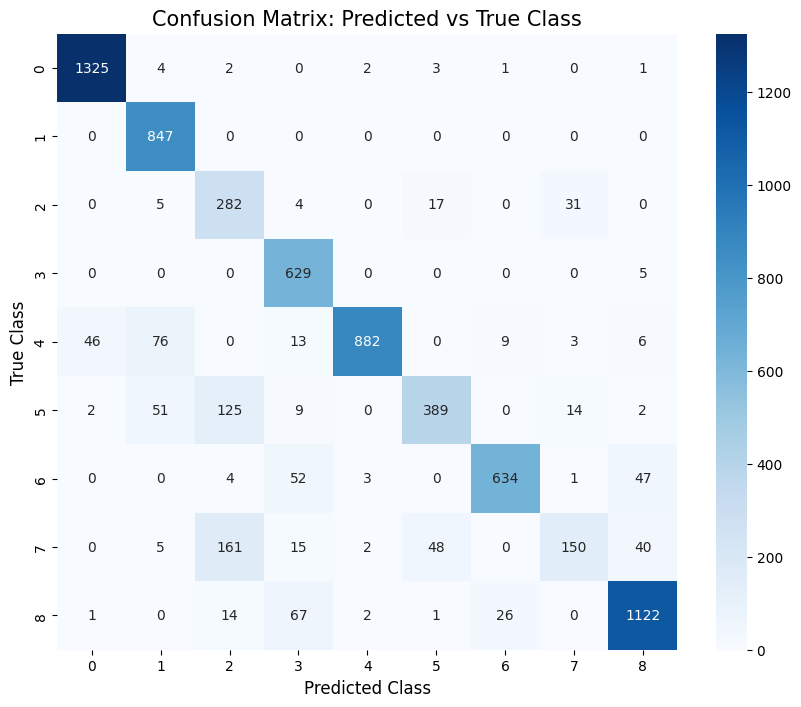

array([[1325,    4,    2,    0,    2,    3,    1,    0,    1],
       [   0,  847,    0,    0,    0,    0,    0,    0,    0],
       [   0,    5,  282,    4,    0,   17,    0,   31,    0],
       [   0,    0,    0,  629,    0,    0,    0,    0,    5],
       [  46,   76,    0,   13,  882,    0,    9,    3,    6],
       [   2,   51,  125,    9,    0,  389,    0,   14,    2],
       [   0,    0,    4,   52,    3,    0,  634,    1,   47],
       [   0,    5,  161,   15,    2,   48,    0,  150,   40],
       [   1,    0,   14,   67,    2,    1,   26,    0, 1122]])

In [35]:
test_acc_cnn, test_cm_cnn = eval_test(cnn, test_loader, device)
print("CNN TEST accuracy:", test_acc_cnn)

# noms des classes (PathMNIST)
class_names = INFO["pathmnist"]["label"]
plot_confusion_matrix(cnn, test_loader, device, class_names)

La matrice de confusion montre que la majorité des prédictions correctes se situent sur la diagonale, ce qui indique que le CNN classe correctement une grande partie des images du jeu de test. Certaines classes sont presque parfaitement reconnues, comme la classe 1 et la classe 3. Cependant, quelques confusions subsistent entre des classes visuellement proches, par exemple entre certaines images des classes 5 et 2 ou entre les classes 7 et 8. Globalement, les résultats montrent que le CNN capture mieux les structures spatiales des images que le modèle MLP utilisé précédemment, ce qui conduit à une amélioration significative des performances de classification

# VIT

In [36]:
class SimpleViT(nn.Module): 
    def __init__(self,img_size=28, patch_size=4, in_channels=3, num_classes=9,embed_dim=128, depth=4, heads=8, mlp_dim=256): 
        super().__init__() 

        assert img_size % patch_size == 0, "Image size must be divisible by patch size"
        self.num_patches = (img_size // patch_size) ** 2 
        self.patch_dim = in_channels * patch_size ** 2 
        self.patch_size = patch_size
        # 1 PATCH EMBEDDING
        self.patch_embedding = nn.Linear(self.patch_dim, embed_dim)


        # 2 CLS TOKEN AND POSITION EMBEDDING
        self.cls_token = nn.Parameter(torch.randn(1,1,embed_dim))
        self.position_embedding = nn.Parameter(torch.randn(1, self.num_patches + 1, embed_dim)) # +1 for cls token

        # 3 TRANSFORMER ENCODER
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=heads, dim_feedforward=mlp_dim, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        #4 CLASSIFIER HEAD
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self,x):
        p = self.patch_size

        # patches extraction
        
        x = x.unfold(2,p,p).unfold(3,p,p) # 2 and 3 because we unfold on height and width , first p is the patch size and second p is the stride (non-overlapping)
        x = x.permute(0,2,3,1,4,5).contiguous() # Put the color channels after the patch dimensions , permute forces pytorch to copy and rearrange the dimensions and contiguous makes sure the memory layout is correct for the next operations

        x = x.view(x.size(0), self.num_patches, -1) # flatten the patch dimensions and color channels into a single dimension for each patch , -1 to let pytorch infer the correct size based on the remaining dimensions

        x = self.patch_embedding(x) # (B, num_patches, embed_dim)

        b , n , _ = x.shape
        cls_token = self.cls_token.expand(b, -1, -1) # copy the cls token for each sample in the batch , -1 means we keep the same size for that dimension
        x = torch.cat((cls_token, x), dim=1) # concatenate the cls token to the patch embeddings
        x = x + self.position_embedding # add the position embedding to the input sequence

        x = self.transformer_encoder(x) # (B, num_patches + 1, embed_dim)

        return self.mlp_head(x[:,0]) # we only use the cls token output for classification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vit_model = SimpleViT().to(device)
print("Model on device:", next(vit_model.parameters()).device)

Model on device: cuda:0


In [37]:
summary(vit_model, input_size=(BATCH_SIZE, CHANNELS, IMG_SIZE[0], IMG_SIZE[1]))

Layer (type:depth-idx)                        Output Shape              Param #
SimpleViT                                     [64, 9]                   6,528
├─Linear: 1-1                                 [64, 49, 128]             6,272
├─TransformerEncoder: 1-2                     [64, 50, 128]             --
│    └─ModuleList: 2-1                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [64, 50, 128]             132,480
│    │    └─TransformerEncoderLayer: 3-2      [64, 50, 128]             132,480
│    │    └─TransformerEncoderLayer: 3-3      [64, 50, 128]             132,480
│    │    └─TransformerEncoderLayer: 3-4      [64, 50, 128]             132,480
├─Sequential: 1-3                             [64, 9]                   --
│    └─LayerNorm: 2-2                         [64, 128]                 256
│    └─Linear: 2-3                            [64, 9]                   1,161
Total params: 544,137
Trainable params: 544,137
Non-trainable par

In [38]:
criterion_vit = nn.CrossEntropyLoss()
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(vit_model.parameters(), lr=LEARNING_RATE_VIT , weight_decay=0.01) # adamW is a variant of Adam that decouples weight decay from the gradient update, which can lead to better generalization performance in some cases, especially for transformer-based models like ViT. 
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_VIT) # CosineAnnealingLR is a learning rate scheduler that adjusts the learning rate following a cosine decay pattern over the course of training. T_max is the number of epochs for one cycle of the cosine decay, meaning that the learning rate will start at the initial value, decrease to a minimum, and then potentially restart if you have multiple cycles. This can help improve convergence and generalization in some cases, especially for transformer-based models like ViT.

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0 

    for inputs, targets in tqdm(loader, desc="Training"): 
        inputs, targets = inputs.to(device), targets.to(device)
        targets = targets.squeeze().long() # Remove extra dimensions and convert to long for CrossEntropyLoss

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0) # Find the total loss
        _, predicted = outputs.max(1) # Get the index of the max log-probability
        total += targets.size(0) # Count the number of seen examples
        correct += predicted.eq(targets).sum().item() # Update correct with the number of correct predictions in the batch, eq returns [True , False , True , True]

    return running_loss / total, 100. * correct / total  # Return average loss and accuracy percentage

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad(): 
        for inputs, targets in tqdm(loader, desc ="Validation"):
            inputs, targets = inputs.to(device), targets.to(device)
            targets = targets.squeeze().long() 

            outputs = model(inputs)
            loss = criterion(outputs,targets)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    return running_loss / total, 100. * correct / total




In [39]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(EPOCHS_VIT):
    print(f"\nEpoch {epoch+1}/{EPOCHS_VIT}")
    
    train_loss, train_acc = train_one_epoch(vit_model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate(vit_model, val_loader, criterion, device)
    
    # Mise à jour du learning rate
    scheduler.step()
    
    # Sauvegarde de l'historique
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")


Epoch 1/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 206.04it/s]


Train Loss: 0.9243 | Train Acc: 64.59%
Val Loss: 0.8446 | Val Acc: 68.87%

Epoch 2/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 213.98it/s]


Train Loss: 0.6274 | Train Acc: 76.81%
Val Loss: 0.4968 | Val Acc: 82.10%

Epoch 3/10


...

Train Loss: 0.2053 | Train Acc: 92.68%
Val Loss: 0.1886 | Val Acc: 93.27%

Epoch 9/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 208.74it/s]


Train Loss: 0.1753 | Train Acc: 93.66%
Val Loss: 0.1502 | Val Acc: 94.91%

Epoch 10/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 195.56it/s]

Train Loss: 0.1590 | Train Acc: 94.23%
Val Loss: 0.1469 | Val Acc: 95.04%


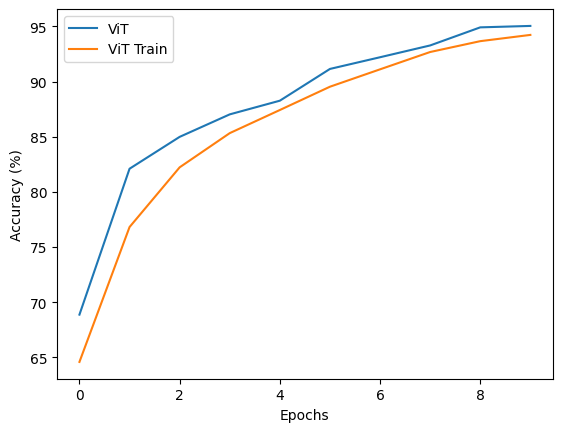

In [40]:
plt.plot(history['val_acc'], label='ViT')
plt.plot(history['train_acc'], label='ViT Train')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()